# A Scale-Cascading Delayed-Equilibration Framework for Nonequilibrium Complexity and Chaos

**Author:** Sagar K.S.  
**Affiliation:** Project Associate, National Centre for Combustion Research and Development, Indian Institute of Technology Madras, India
**Contact:** SagarKS.Correspondence@pm.me

---

### Abstract

A unified energy-balance framework is developed in which deterministic chaos and spatiotemporal complexity are characterized as continuous cascades of delayed equilibration across interacting scales. Thermodynamic drive, structural feedback, and memory are synthesized into a single Equilibration Number ($\mathcal{E}$) that governs the onset of macroscopic instability. A global boundedness theorem is proved for the proposed nonlinear delayed energy model via the Lyapunov–Razumikhin method. The framework provides a unified interpretation of zero-dimensional temporal dynamics and multi-scale spatial cascades through a structured dual-axis theoretical architecture. Under quadratic saturation assumptions, the canonical Feigenbaum period-doubling route to chaos is shown to emerge as the infinite-delay limit of continuous macroscopic equilibration. Extending this discrete limit to spatial cascades suggests a mechanism for the onset of multifractal intermittency. The thermodynamic energy flux is coupled to phase-space limit cycles via a non-autonomous Kuramoto model. By incorporating geometric amplitude scaling across cascade levels, the framework indicates that spatiotemporal cascades produce intermittent bursting, characterized by alternating regimes of strong phase-enslavement and chaotic phase-slipping, providing a systematically motivated description of spatiotemporal intermittency without relying on ad hoc phenomenological statistics, This Python Notebook contain the code used to generate the data precented in the paper

---

**Dependencies:** `numpy`, `scipy`, `pandas`, `matplotlib`

---
## RK4 DDE Solver

Custom fixed-step fourth-order Runge–Kutta integrator for delay differential equations (DDEs),
with cubic Hermite interpolation for delayed-state evaluation.

In [12]:
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp, odeint
from scipy.signal import find_peaks
import os, csv

OUT_DIR = os.getcwd()
os.makedirs(OUT_DIR, exist_ok=True)

def rk4_dde(f, history, t_max, dt, tau):
    """
    Integrates dx/dt = f(x(t), x(t-tau)) using 4th-order Runge-Kutta.
    history: initial function array of length N_tau + 1.
    f: takes arguments (x_t, x_tau).
    Returns the full trajectory.
    """
    N_tau = 0 if tau == 0 else int(np.round(tau / dt))
    steps = int(np.round(t_max / dt))
    x = np.zeros(steps)
    if N_tau > 0:
        x[:N_tau+1] = history[-N_tau-1:]
        start_idx = N_tau
    else:
        x[0] = history[-1]
        start_idx = 0
    for i in range(start_idx, steps - 1):
        if N_tau > 1 and i >= N_tau + 1 and i < steps - 2:
            x_tau_0 = x[i - N_tau]
            x_tau_mid = (-0.0625*x[i-N_tau-1] + 0.5625*x[i-N_tau]
                         + 0.5625*x[i-N_tau+1] - 0.0625*x[i-N_tau+2])
            x_tau_1 = x[i - N_tau + 1]
        elif N_tau > 0:
            x_tau_0 = x[i - N_tau]
            x_tau_mid = 0.5*(x[i-N_tau] + x[i-N_tau+1])
            x_tau_1 = x[i - N_tau + 1]
        else:
            x_tau_0 = x_tau_mid = x_tau_1 = x[i]
        k1 = f(x[i], x_tau_0)
        k2 = f(x[i] + 0.5*dt*k1, x_tau_mid)
        k3 = f(x[i] + 0.5*dt*k2, x_tau_mid)
        k4 = f(x[i] + dt*k3, x_tau_1)
        x[i+1] = x[i] + (dt/6.0)*(k1 + 2*k2 + 2*k3 + k4)
    return x


def rk4_dde_system(f, history, t_max, dt, taus):
    """
    Integrates a system of DDEs: dX/dt = f(X(t), X_delayed).
    history: shape (N_tau_max + 1, num_vars).
    taus: list of delays for each variable.
    """
    num_vars = history.shape[1]
    N_taus = [int(np.round(tau / dt)) for tau in taus]
    max_N_tau = max(N_taus) if N_taus else 0
    steps = int(np.round(t_max / dt))
    X = np.zeros((steps, num_vars))
    if max_N_tau > 0:
        X[:max_N_tau+1, :] = history[-max_N_tau-1:, :]
        start_idx = max_N_tau
    else:
        X[0, :] = history[-1, :]
        start_idx = 0
    for i in range(start_idx, steps - 1):
        X_curr = X[i, :]
        X_tau_0 = np.zeros(num_vars)
        X_tau_mid = np.zeros(num_vars)
        X_tau_1 = np.zeros(num_vars)
        for j, N_tau in enumerate(N_taus):
            if N_tau > 1 and i >= N_tau + 1 and i < steps - 2:
                X_tau_0[j] = X[i-N_tau, j]
                X_tau_mid[j] = (-0.0625*X[i-N_tau-1,j] + 0.5625*X[i-N_tau,j]
                                + 0.5625*X[i-N_tau+1,j] - 0.0625*X[i-N_tau+2,j])
                X_tau_1[j] = X[i-N_tau+1, j]
            elif N_tau > 0:
                X_tau_0[j] = X[i-N_tau, j]
                X_tau_mid[j] = 0.5*(X[i-N_tau,j] + X[i-N_tau+1,j])
                X_tau_1[j] = X[i-N_tau+1, j]
            else:
                X_tau_0[j] = X_curr[j]
                X_tau_mid[j] = X_curr[j]
        k1 = f(X_curr, X_tau_0)
        X_mid1 = X_curr + 0.5*dt*k1
        for j, N_tau in enumerate(N_taus):
            if N_tau == 0: X_tau_mid[j] = X_mid1[j]
        k2 = f(X_mid1, X_tau_mid)
        X_mid2 = X_curr + 0.5*dt*k2
        for j, N_tau in enumerate(N_taus):
            if N_tau == 0: X_tau_mid[j] = X_mid2[j]
        k3 = f(X_mid2, X_tau_mid)
        X_next = X_curr + dt*k3
        for j, N_tau in enumerate(N_taus):
            if N_tau == 0: X_tau_1[j] = X_next[j]
        k4 = f(X_next, X_tau_1)
        X[i+1, :] = X_curr + (dt/6.0)*(k1 + 2*k2 + 2*k3 + k4)
    return X

print('DDE solver loaded.')

DDE solver loaded.


---
## Figure 2: Numerical validation of the derived dimensionless energy-balance model against the canonical Mackey-Glass equation

Parameters: β = 0.2, γ = 0.1, ν = 10, τ = 20, yielding dimensionless values r = β/γ = 2.0, τ̂ = γτ = 2.0, p = 0. Both models integrated via fixed-step RK4 with Δt = 0.1 (dimensional) over t_max = 8000, with 2000 time units of transient discarded. Initial history: x(θ) = 0.5 for θ ∈ [−τ̂, 0]. (a) The time series for both models overlay, consistent with identical chaotic dynamics. (b) The corresponding phase-space strange attractors in the (x(θ−τ̂), x(θ)) embedding are visually indistinguishable.

Running Original MG...
Running Derived MG...
Saved c:\Users\sagar\OneDrive\Desktop\Chaous\Journal\Template_for_Submission_to_AIP_Publishing_Journals\Demo\For_GitHub\MG_comparison_data.csv


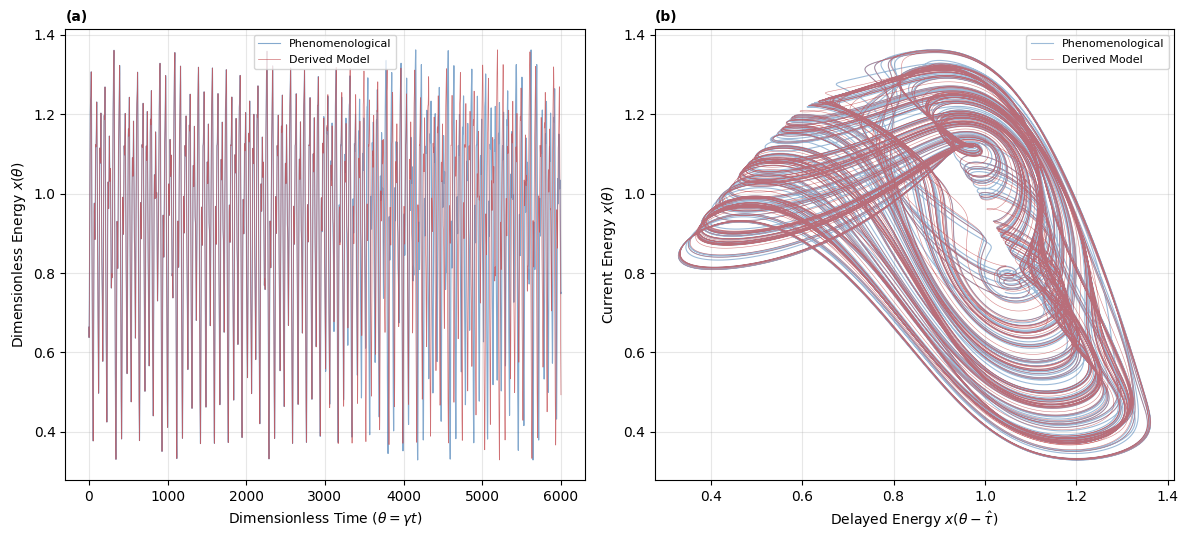

Figure 2 complete.


In [13]:
# ============================================================
# Figure 2: Mackey-Glass Validation
# ============================================================
beta_mg, gamma_mg, n_mg, tau_mg = 0.2, 0.1, 10.0, 20.0
p_mg, r_mg, nu_mg = 0.0, beta_mg/gamma_mg, n_mg
tau_dimless = gamma_mg * tau_mg

def f_orig(x, x_tau):
    return beta_mg * x_tau / (1.0 + x_tau**n_mg) - gamma_mg * x

def f_derived(x, x_tau):
    return p_mg - x + r_mg * x_tau / (1.0 + x_tau**nu_mg)

dt_mg = 0.1
t_max_mg = 8000.0
dt_dimless = dt_mg * gamma_mg

N_tau_orig = int(np.round(tau_mg / dt_mg))
N_tau_dim = int(np.round(tau_dimless / dt_dimless))
history_orig = np.ones(N_tau_orig + 1) * 0.5
history_deriv = np.ones(N_tau_dim + 1) * 0.5

print('Running Original MG...')
x_orig = rk4_dde(f_orig, history_orig, t_max_mg, dt_mg, tau_mg)
print('Running Derived MG...')
x_derived = rk4_dde(f_derived, history_deriv, t_max_mg*gamma_mg, dt_dimless, tau_dimless)

skip = int(2000 / dt_mg)
x_o, x_d = x_orig[skip:], x_derived[skip:]
t_o = np.arange(len(x_o)) * dt_mg
t_d_raw = np.arange(len(x_d)) * dt_dimless
t_d_mapped = t_d_raw / gamma_mg

delay_o = int(np.round(tau_mg / dt_mg))
delay_d = int(np.round(tau_dimless / dt_dimless))
x_o_tau = x_orig[skip - delay_o : len(x_orig) - delay_o]
x_d_tau = x_derived[skip - delay_d : len(x_derived) - delay_d]

min_len = min(len(x_o), len(x_d))
residual = x_o[:min_len] - x_d[:min_len]

# Save CSV
csv_path = os.path.join(OUT_DIR, 'MG_comparison_data.csv')
with open(csv_path, 'w', newline='') as f:
    w = csv.writer(f)
    w.writerow(['Time (t)', 'Original_Delayed', 'Original_Current',
                'Derived_Delayed', 'Derived_Current', 'Residual_Error'])
    for i in range(0, min_len, 10):
        w.writerow([t_o[i], x_o_tau[i], x_o[i], x_d_tau[i], x_d[i], residual[i]])
print(f'Saved {csv_path}')

# Plot
fig, axes = plt.subplots(1, 2, figsize=(12, 5.5))
axes[0].plot(t_o, x_o, color='#0b559f', alpha=0.5, lw=0.8, label='Phenomenological')
axes[0].plot(t_d_mapped[:len(x_d)], x_d, color='#c44e52', alpha=0.8, lw=0.5, label='Derived Model')
axes[0].set_xlabel(r'Dimensionless Time ($\theta = \gamma t$)')
axes[0].set_ylabel(r'Dimensionless Energy $x(\theta)$')
axes[0].set_title('(a)', loc='left', fontweight='bold', fontsize=10)
axes[0].legend(fontsize=8); axes[0].grid(True, alpha=0.3)

axes[1].plot(x_o_tau, x_o, color='#0b559f', alpha=0.4, lw=0.8, label='Phenomenological')
axes[1].plot(x_d_tau, x_d, color='#c44e52', alpha=0.7, lw=0.4, label='Derived Model')
axes[1].set_xlabel(r'Delayed Energy $x(\theta - \hat{\tau})$')
axes[1].set_ylabel(r'Current Energy $x(\theta)$')
axes[1].set_title('(b)', loc='left', fontweight='bold', fontsize=10)
axes[1].legend(fontsize=8); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
fig.savefig(os.path.join(OUT_DIR, 'fig_mg_validation.png'), dpi=300, bbox_inches='tight')
plt.show()
print('Figure 2 complete.')

---
## Figure 3: The onset of chaos in delayed energy-balance models

Mackey-Glass parameters: β = 2.0, γ = 1.0, ν = 10. Integrated via fixed-step RK4 (Δt = 0.05, t_max = 1000) over 100 values of τ ∈ [0.5, 4.0]. (a) Bifurcation diagram of local maxima vs. dimensionless delay Π = kτ. (b) The maximal Lyapunov exponent λ_max (Benettin’s method, δ = 10⁻⁶, renormalization interval 2.0) and the time-averaged disequilibrium Q̄.

In [14]:
# ============================================================
# Figure 3: Chaos Indicators
# ============================================================
beta_ci, gamma_ci, n_ci = 2.0, 1.0, 10

def mg_ci(x, x_tau):
    return beta_ci * x_tau / (1.0 + x_tau**n_ci) - gamma_ci * x

tau_range = np.linspace(0.5, 4.0, 100)
dt_ci, t_max_ci = 0.05, 1000
tau_c = 1.48
bif_pts, ind_data = [], []

for tau in tau_range:
    N_tau = int(np.round(tau / dt_ci))
    hist = np.ones(N_tau + 1) * 0.5
    x_b = rk4_dde(mg_ci, hist, t_max_ci, dt_ci, tau)
    trans = int(t_max_ci/2/dt_ci)
    x_ss = x_b[trans:]
    dx = np.gradient(x_ss, dt_ci)
    Q_avg = np.mean(dx**2)
    # Lyapunov
    t_ly = 2000; s_ly = int(t_ly/dt_ci); rn_s = int(2.0/dt_ci)
    h1 = x_b[-N_tau-1:] if N_tau > 0 else np.array([x_b[-1]])
    h2 = h1 + 1e-6
    x1, x2 = np.zeros(s_ly), np.zeros(s_ly)
    x1[:N_tau+1], x2[:N_tau+1] = h1, h2
    si = N_tau if N_tau > 0 else 0
    sld, rc, d0 = 0.0, 0, 1e-6
    for i in range(si, s_ly-1):
        xt01 = x1[i-N_tau] if N_tau>0 else x1[i]
        xtm1 = 0.5*(x1[i-N_tau]+x1[i-N_tau+1]) if N_tau>0 else x1[i]
        xt11 = x1[i-N_tau+1] if N_tau>0 else x1[i]
        xt02 = x2[i-N_tau] if N_tau>0 else x2[i]
        xtm2 = 0.5*(x2[i-N_tau]+x2[i-N_tau+1]) if N_tau>0 else x2[i]
        xt12 = x2[i-N_tau+1] if N_tau>0 else x2[i]
        k11=mg_ci(x1[i],xt01); k21=mg_ci(x1[i]+.5*dt_ci*k11,xtm1)
        k31=mg_ci(x1[i]+.5*dt_ci*k21,xtm1); k41=mg_ci(x1[i]+dt_ci*k31,xt11)
        x1[i+1]=x1[i]+(dt_ci/6)*(k11+2*k21+2*k31+k41)
        k12=mg_ci(x2[i],xt02); k22=mg_ci(x2[i]+.5*dt_ci*k12,xtm2)
        k32=mg_ci(x2[i]+.5*dt_ci*k22,xtm2); k42=mg_ci(x2[i]+dt_ci*k32,xt12)
        x2[i+1]=x2[i]+(dt_ci/6)*(k12+2*k22+2*k32+k42)
        if i>si and i%rn_s==0:
            w1=x1[i+1-N_tau:i+2] if N_tau>0 else np.array([x1[i+1]])
            w2=x2[i+1-N_tau:i+2] if N_tau>0 else np.array([x2[i+1]])
            d=np.max(np.abs(w1-w2))
            if d>0:
                sld+=np.log(d/d0); rc+=1
                if N_tau>0: x2[i+1-N_tau:i+2]=w1+(d0/d)*(w2-w1)
                else: x2[i+1]=w1[0]+(d0/d)*(w2[0]-w1[0])
    lam_max = sld/(rc*rn_s*dt_ci) if rc>0 else 0.0
    ind_data.append({'tau':tau, 'Ratio_Rgen_Req':tau/tau_c, 'Q_avg':Q_avg, 'lambda_max':lam_max})
    x_tail = x_b[-int(len(x_b)*0.2):]
    pks = [x_tail[i] for i in range(1,len(x_tail)-1) if x_tail[i-1]<x_tail[i] and x_tail[i]>x_tail[i+1]]
    step_s = max(1, len(pks)//50)
    for p in pks[::step_s][:50]:
        bif_pts.append({'tau':tau, 'Ratio_Rgen_Req':tau/tau_c, 'Local_Max':p})

df_bif = pd.DataFrame(bif_pts); df_ind = pd.DataFrame(ind_data)
df_bif.to_csv(os.path.join(OUT_DIR, 'Chaos_Bifurcation.csv'), index=False)
df_ind.to_csv(os.path.join(OUT_DIR, 'Chaos_Indicators.csv'), index=False)
print(f'Saved Chaos_Bifurcation.csv ({len(df_bif)} rows) and Chaos_Indicators.csv ({len(df_ind)} rows)')
print('Figure 3 data complete. (Rendered inline by LaTeX/pgfplots in the paper.)')

Saved Chaos_Bifurcation.csv (4992 rows) and Chaos_Indicators.csv (100 rows)
Figure 3 data complete. (Rendered inline by LaTeX/pgfplots in the paper.)


---
## Figure 4: Time evolution of the dimensionless macroscopic thermodynamic gradient intensity Q_L(t) in the Lorenz model

Parameters: σ = 10, b_L = 8/3; initial conditions X₀ = (1, 1, 1); integrated via RK45 (Dormand–Prince) over t ∈ [0, 20] with 4000 evaluation points. (a) Stable regime (r = 10): intensity decays to zero. (b) Chaotic regime (r = 28): erratic, high-amplitude bursting. (c) Periodic window (r = 160): permanent periodic frustration.

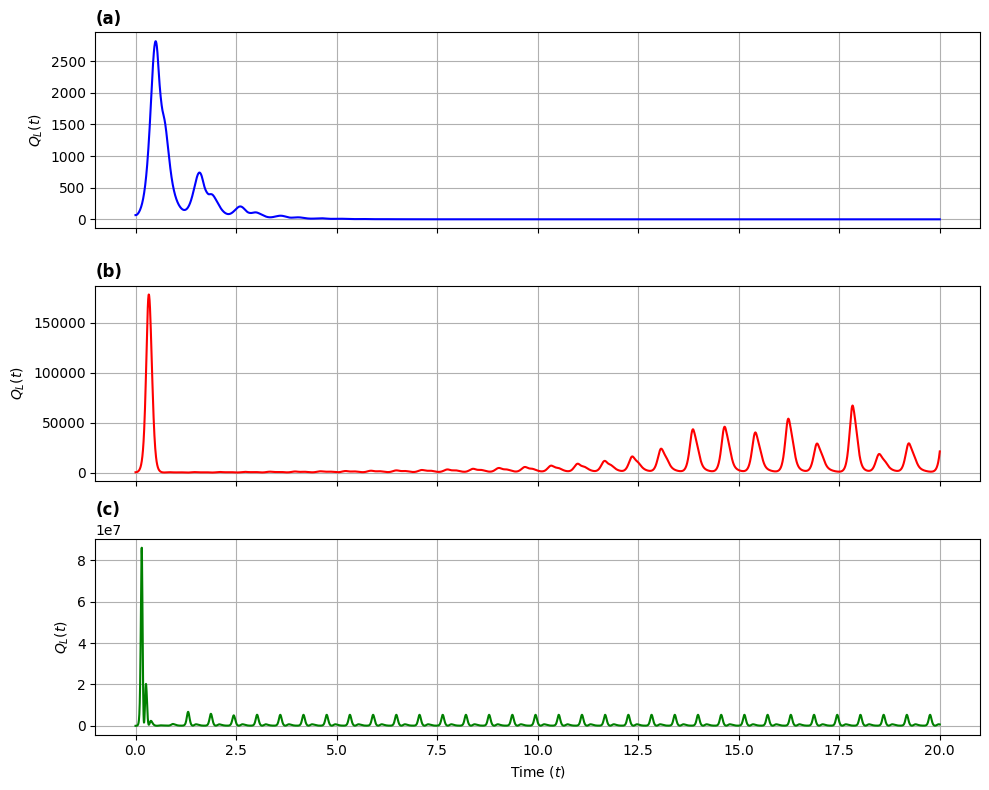

Figure 4 complete.


In [15]:
# ============================================================
# Figure 4: Lorenz Disequilibrium Q(t)
# ============================================================
sigma_L, b_L = 10.0, 8.0/3.0

def lorenz(t, state, r):
    x, y, z = state
    return [sigma_L*(y-x), x*(r-z)-y, x*y-b_L*z]

def calc_Q(y_arr, r):
    x, y, z = y_arr[0], y_arr[1], y_arr[2]
    dx, dy, dz = sigma_L*(y-x), x*(r-z)-y, x*y-b_L*z
    return dx**2 + dy**2 + dz**2

t_span_Q = (0, 20)
t_eval_Q = np.linspace(0, 20, 4000)
s0 = [1.0, 1.0, 1.0]

sol_s = solve_ivp(lorenz, t_span_Q, s0, args=(10.0,), t_eval=t_eval_Q)
sol_c = solve_ivp(lorenz, t_span_Q, s0, args=(28.0,), t_eval=t_eval_Q)
sol_p = solve_ivp(lorenz, t_span_Q, s0, args=(160.0,), t_eval=t_eval_Q)

Q_s, Q_c, Q_p = calc_Q(sol_s.y,10), calc_Q(sol_c.y,28), calc_Q(sol_p.y,160)

df_Q = pd.DataFrame({'Time':t_eval_Q, 'Q_Stable':Q_s, 'Q_Chaotic':Q_c, 'Q_Oscillatory':Q_p})
df_Q.to_csv(os.path.join(OUT_DIR, 'Lorenz_Q_data.csv'), index=False)
df_Q.iloc[::4].to_csv(os.path.join(OUT_DIR, 'Lorenz_Q_data_small.csv'), index=False)

fig, axs = plt.subplots(3, 1, figsize=(10, 8), sharex=True)
axs[0].plot(t_eval_Q, Q_s, color='blue'); axs[0].set_title('(a)',loc='left',fontweight='bold')
axs[0].set_ylabel(r'$Q_L(t)$'); axs[0].grid(True)
axs[1].plot(t_eval_Q, Q_c, color='red'); axs[1].set_title('(b)',loc='left',fontweight='bold')
axs[1].set_ylabel(r'$Q_L(t)$'); axs[1].grid(True)
axs[2].plot(t_eval_Q, Q_p, color='green'); axs[2].set_title('(c)',loc='left',fontweight='bold')
axs[2].set_ylabel(r'$Q_L(t)$'); axs[2].set_xlabel('Time ($t$)'); axs[2].grid(True)
plt.tight_layout()
fig.savefig(os.path.join(OUT_DIR, 'fig_lorenz_Q.png'), dpi=300, bbox_inches='tight')
plt.show()
print('Figure 4 complete.')

---
## Figure 7: Numerical verification of the Equilibration Number phase diagram using the Mackey-Glass DDE

For fixed parameters β = 2.0, γ = 1.0, ν = 10, the delay τ is swept from 0.05 to 5.0 across 200 values, with E = |χΦ′(R)| · 2Π/π = 8τ/π computed analytically. (a) Bifurcation diagram. (b) Maximal Lyapunov exponent λ_max.

In [16]:
# ============================================================
# Figure 7: Equilibration Number Phase Diagram
# ============================================================
beta_E, gamma_E, nu_E = 2.0, 1.0, 10.0

def mg_E(x, x_tau):
    return beta_E * x_tau / (1.0 + x_tau**nu_E) - gamma_E * x

def compute_E(tau): return 8.0 * tau / np.pi

tau_vals = np.linspace(0.05, 5.0, 200)
dt_E, t_max_E, t_trans_E = 0.05, 1500, 750
bif_E, ind_E = [], []

for idx, tau in enumerate(tau_vals):
    E_val = compute_E(tau)
    N_tau = int(np.round(tau/dt_E))
    hist = np.ones(N_tau+1)*0.5
    x_b = rk4_dde(mg_E, hist, t_max_E, dt_E, tau)
    tr = int(t_trans_E/dt_E)
    x_ss = x_b[tr:]
    dx = np.gradient(x_ss, dt_E)
    Q_avg = np.mean(dx**2)
    # Lyapunov
    t_ly=2000; s_ly=int(t_ly/dt_E); rn_s=int(2.0/dt_E)
    h1 = x_b[-N_tau-1:] if N_tau>0 else np.array([x_b[-1]])
    h2 = h1+1e-6
    x1,x2 = np.zeros(s_ly), np.zeros(s_ly)
    x1[:N_tau+1],x2[:N_tau+1] = h1,h2
    si = N_tau if N_tau>0 else 0
    sld,rc,d0 = 0.0,0,1e-6
    for i in range(si,s_ly-1):
        xt01=x1[i-N_tau] if N_tau>0 else x1[i]
        xtm1=0.5*(x1[i-N_tau]+x1[i-N_tau+1]) if N_tau>0 else x1[i]
        xt11=x1[i-N_tau+1] if N_tau>0 else x1[i]
        xt02=x2[i-N_tau] if N_tau>0 else x2[i]
        xtm2=0.5*(x2[i-N_tau]+x2[i-N_tau+1]) if N_tau>0 else x2[i]
        xt12=x2[i-N_tau+1] if N_tau>0 else x2[i]
        k11=mg_E(x1[i],xt01); k21=mg_E(x1[i]+.5*dt_E*k11,xtm1)
        k31=mg_E(x1[i]+.5*dt_E*k21,xtm1); k41=mg_E(x1[i]+dt_E*k31,xt11)
        x1[i+1]=x1[i]+(dt_E/6)*(k11+2*k21+2*k31+k41)
        k12=mg_E(x2[i],xt02); k22=mg_E(x2[i]+.5*dt_E*k12,xtm2)
        k32=mg_E(x2[i]+.5*dt_E*k22,xtm2); k42=mg_E(x2[i]+dt_E*k32,xt12)
        x2[i+1]=x2[i]+(dt_E/6)*(k12+2*k22+2*k32+k42)
        if i>si and i%rn_s==0:
            w1=x1[i+1-N_tau:i+2] if N_tau>0 else np.array([x1[i+1]])
            w2=x2[i+1-N_tau:i+2] if N_tau>0 else np.array([x2[i+1]])
            d=np.max(np.abs(w1-w2))
            if d>0:
                sld+=np.log(d/d0); rc+=1
                if N_tau>0: x2[i+1-N_tau:i+2]=w1+(d0/d)*(w2-w1)
                else: x2[i+1]=w1[0]+(d0/d)*(w2[0]-w1[0])
    lam_max=sld/(rc*rn_s*dt_E) if rc>0 else 0.0
    ind_E.append({'E':E_val,'tau':tau,'Q_avg':Q_avg,'lambda_max':lam_max})
    x_tail=x_b[-int(len(x_b)*0.2):]
    pks=[x_tail[i] for i in range(1,len(x_tail)-1) if x_tail[i-1]<x_tail[i] and x_tail[i]>x_tail[i+1]]
    if pks:
        ss=max(1,len(pks)//50)
        for p in pks[::ss][:50]: bif_E.append({'E':E_val,'tau':tau,'Local_Max':p})
    else:
        bif_E.append({'E':E_val,'tau':tau,'Local_Max':x_b[-1]})
    if idx%40==0: print(f'  [{idx+1}/{len(tau_vals)}] E={E_val:.2f}, \u03bb_max={lam_max:.4f}')

df_bE = pd.DataFrame(bif_E); df_iE = pd.DataFrame(ind_E)
df_bE.to_csv(os.path.join(OUT_DIR, 'E_Bifurcation.csv'), index=False)
df_bE_thin = df_bE.sample(frac=0.1, random_state=42).sort_values('E')
df_bE_thin.to_csv(os.path.join(OUT_DIR, 'E_Bifurcation_thin.csv'), index=False)
df_iE.to_csv(os.path.join(OUT_DIR, 'E_Indicators.csv'), index=False)
print(f'Saved E_Bifurcation.csv ({len(df_bE)} rows), E_Indicators.csv ({len(df_iE)} rows)')
print('Figure 7 data complete. (Rendered inline by LaTeX/pgfplots in the paper.)')

  [1/200] E=0.13, λ_max=-6.6201
  [41/200] E=2.66, λ_max=0.0002
  [81/200] E=5.19, λ_max=0.0754
  [121/200] E=7.73, λ_max=0.0588
  [161/200] E=10.26, λ_max=0.0354
Saved E_Bifurcation.csv (9118 rows), E_Indicators.csv (200 rows)
Figure 7 data complete. (Rendered inline by LaTeX/pgfplots in the paper.)


---
## Figure 8: The emergence of the discrete Logistic Map from continuous delayed equilibration

(a) The empirical return map of the macroscopic convection peaks (Z_{n+1} vs Z_n) generated by the fully continuous Lorenz ODEs at r = 28. (b) The canonical period-doubling bifurcation cascade to chaos produced by simulating the normalized discrete Logistic Map.

In [17]:
# ============================================================
# Figure 8: Feigenbaum-Lorenz Duality
# ============================================================
# (a) Lorenz Return Map
def lorenz_feig(t, state, sigma, r, b):
    x,y,z = state
    return [sigma*(y-x), x*(r-z)-y, x*y-b*z]

sol_feig = solve_ivp(lorenz_feig, (0,100), [1,1,1], args=(10,28,8/3),
                     t_eval=np.linspace(0,100,10000), rtol=1e-8, atol=1e-8)
z_d = sol_feig.y[2]
peaks_idx, _ = find_peaks(z_d)
z_pks = z_d[peaks_idx]
Zn, Znp1 = z_pks[:-1], z_pks[1:]

pd.DataFrame({'Zn':Zn,'Znp1':Znp1}).to_csv(os.path.join(OUT_DIR,'Lorenz_Return_Map.csv'), index=False)

# (b) Logistic Bifurcation
r_vals_log = np.linspace(2.5, 4.0, 400)
r_col, x_col = [], []
for r in r_vals_log:
    x = 0.5
    for _ in range(500): x = r*x*(1-x)
    for _ in range(30):
        x = r*x*(1-x)
        r_col.append(r); x_col.append(x)

pd.DataFrame({'E':r_col,'x':x_col}).to_csv(os.path.join(OUT_DIR,'Logistic_Bifurcation.csv'), index=False)
print('Saved Lorenz_Return_Map.csv and Logistic_Bifurcation.csv')
print('Figure 8 data complete. (Rendered inline by LaTeX/pgfplots in the paper.)')

Saved Lorenz_Return_Map.csv and Logistic_Bifurcation.csv
Figure 8 data complete. (Rendered inline by LaTeX/pgfplots in the paper.)


---
## Figure 9: The emergence of macroscopic coherent structures via Kuramoto phase synchronization

N = 50 oscillators. Natural frequencies drawn from ω_i ~ N(μ = 1.0, σ_ω = 0.5); initial phases θ_i(0) ~ Uniform[0, 2π]; integrated via LSODA over t ∈ [0, 30] (seed 42). Three coupling regimes: frustrated (K = 0.5), critical (K_c ≈ 0.8), synchronized (K = 2.5).

In [18]:
# ============================================================
# Figure 9: Kuramoto Phase Synchronization
# ============================================================
N_k = 50
np.random.seed(42)
omega_k = np.random.normal(loc=1.0, scale=0.5, size=N_k)
theta0_k = np.random.uniform(0, 2*np.pi, N_k)

def kuramoto(theta, t, K, omega, N):
    dtheta = np.zeros(N)
    for i in range(N):
        dtheta[i] = omega[i] + (K/N)*np.sum(np.sin(theta - theta[i]))
    return dtheta

def order_param(theta):
    return np.abs(np.mean(np.exp(1j*theta), axis=1))

t_k = np.linspace(0, 30, 600)
R_low = order_param(odeint(kuramoto, theta0_k, t_k, args=(0.5, omega_k, N_k)))
R_crit = order_param(odeint(kuramoto, theta0_k, t_k, args=(0.8, omega_k, N_k)))
R_high = order_param(odeint(kuramoto, theta0_k, t_k, args=(2.5, omega_k, N_k)))

df_kur = pd.DataFrame({'Time':t_k, 'R_Low':R_low, 'R_Crit':R_crit, 'R_High':R_high})
df_kur.to_csv(os.path.join(OUT_DIR, 'Kuramoto_data.csv'), index=False)
print('Saved Kuramoto_data.csv')
print('Figure 9 data complete. (Rendered inline by LaTeX/pgfplots in the paper.)')

Saved Kuramoto_data.csv
Figure 9 data complete. (Rendered inline by LaTeX/pgfplots in the paper.)


---
## Figure 10: Phase space mapping of the Volterra integro-differential energy-balance model

Parameters: β = 2.0, γ = 1.0, ν = 10, with a Gamma kernel of shape p = 10 and mean delay τ_mean = p/α = 20.0 (α = 0.5). The infinite-dimensional DDE is converted into p + 1 = 11 coupled ODEs via the linear chain trick and integrated via LSODA over t ∈ [0, 3000] (Δt = 0.1, first 1000 time units discarded as transient).

In [19]:
# ============================================================
# Figure 10: Distributed Memory Attractor
# ============================================================
beta_dm, gamma_dm, n_dm = 2.0, 1.0, 10.0
tau_mean_dm, p_dm = 20.0, 10
alpha_dm = p_dm / tau_mean_dm

def gamma_kernel_mg(state, t, beta, gamma, n, alpha, p):
    x = state[0]; y = state[1:]
    delayed_x = y[-1]
    dxdt = beta * delayed_x / (1.0 + delayed_x**n) - gamma * x
    dy = np.zeros(p)
    dy[0] = alpha * (x - y[0])
    for i in range(1, p): dy[i] = alpha * (y[i-1] - y[i])
    return [dxdt] + list(dy)

t_dm = np.linspace(0, 3000, 30000)
state0_dm = [1.01] + [1.0]*p_dm
sol_dm = odeint(gamma_kernel_mg, state0_dm, t_dm, args=(beta_dm, gamma_dm, n_dm, alpha_dm, p_dm))

t_plot_dm = t_dm[10000:]; x_plot_dm = sol_dm[10000:,0]; y_plot_dm = sol_dm[10000:,-1]

df_dm = pd.DataFrame({'Time':t_plot_dm, 'x':x_plot_dm, 'Delayed_x':y_plot_dm})
df_dm.to_csv(os.path.join(OUT_DIR, 'Distributed_Memory_data.csv'), index=False)
print('Saved Distributed_Memory_data.csv')
print('Figure 10 data complete. (Rendered inline by LaTeX/pgfplots in the paper.)')

Saved Distributed_Memory_data.csv
Figure 10 data complete. (Rendered inline by LaTeX/pgfplots in the paper.)


---
## Figure 12: Numerical integration of the fully coupled Mackey–Glass Energy Cascade across three geometric scales

Base parameters: β₀ = 2.0, E_{c,0} = 1.0, d₀ = 0.05, τ₀ = 3.0, ν = 10, F_in = 1.5, inter-scale ratio λ = 2.0. Geometric scaling: τ_n = τ₀λ^{−2n/3}, β_n = β₀λ^{2n/3}, E_{c,n} = E_{c,0}λ^{−2n/3}, d_n = d₀λ^{2n}. Integrated via fixed-step RK4 (Δt = 0.01, T = 200). (a) Macroscopic scale. (b) Inertial scale. (c) Microscopic scale.

Running MG Cascade...


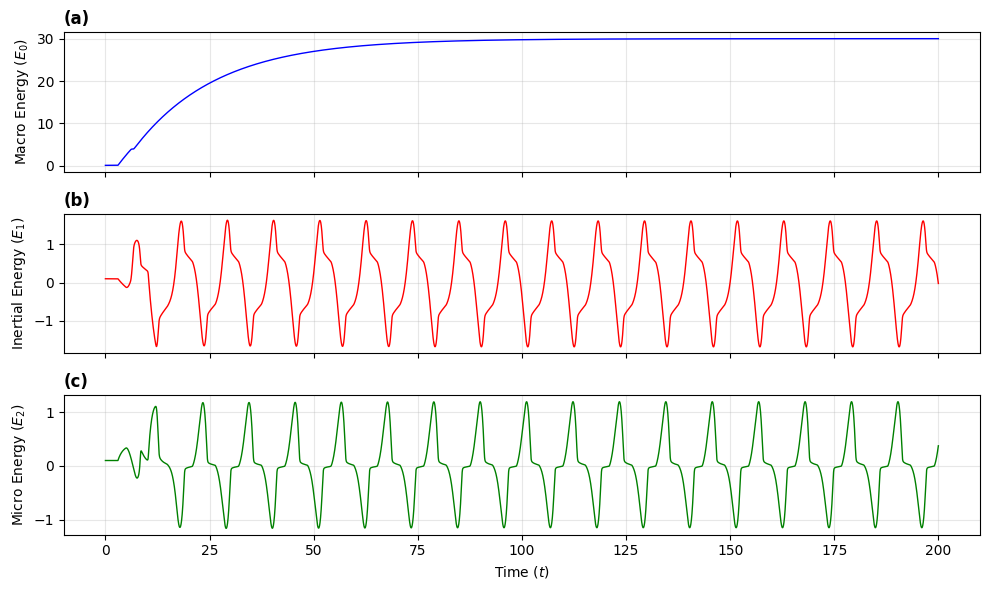

Figure 12 complete.


In [20]:
# ============================================================
# Figure 12: Mackey-Glass Cascade (3 Scales)
# ============================================================
lam_mg = 2.0; tau0_mg = 3.0; beta0_mg = 2.0; Ec0_mg = 1.0; d0_mg = 0.05
nu_mg_c = 10.0; Fin_mg = 1.5; N_scales = 3

def get_mg_params(n):
    tau = tau0_mg * lam_mg**(-2.0*n/3.0)
    beta = beta0_mg * lam_mg**(2.0*n/3.0)
    Ec = Ec0_mg * lam_mg**(-2.0*n/3.0)
    d = d0_mg * lam_mg**(2.0*n)
    return tau, beta, Ec, d

taus_c, betas_c, Ecs_c, ds_c = [], [], [], []
for n in range(N_scales):
    t, b, e, d = get_mg_params(n)
    taus_c.append(t); betas_c.append(b); Ecs_c.append(e); ds_c.append(d)

def mg_cascade_f(E, E_delayed):
    dE = np.zeros(N_scales)
    fluxes = [(betas_c[n]*E_delayed[n])/(1.0+(E_delayed[n]/Ecs_c[n])**nu_mg_c) for n in range(N_scales)]
    dE[0] = Fin_mg - fluxes[0] - ds_c[0]*E[0]
    dE[1] = fluxes[0] - fluxes[1] - ds_c[1]*E[1]
    dE[2] = fluxes[1] - ds_c[2]*E[2]
    return dE

dt_c = 0.01; T_c = 200.0
max_tau_c = max(taus_c); max_N_tau_c = int(np.round(max_tau_c/dt_c))
history_c = np.ones((max_N_tau_c+1, N_scales))*0.1

print('Running MG Cascade...')
E_out = rk4_dde_system(mg_cascade_f, history_c, T_c, dt_c, taus_c)
time_c = np.arange(E_out.shape[0])*dt_c

df_c = pd.DataFrame({'t':time_c, 'E0':E_out[:,0], 'E1':E_out[:,1], 'E2':E_out[:,2]})
df_c.iloc[::10].to_csv(os.path.join(OUT_DIR, 'MG_Cascade_Data.csv'), index=False)

fig, axs = plt.subplots(3, 1, figsize=(10, 6), sharex=True)
axs[0].plot(time_c, E_out[:,0], 'b-', lw=1); axs[0].set_ylabel(r'Macro Energy ($E_0$)')
axs[0].set_title('(a)',loc='left',fontweight='bold'); axs[0].grid(True,alpha=0.3)
axs[1].plot(time_c, E_out[:,1], 'r-', lw=1); axs[1].set_ylabel(r'Inertial Energy ($E_1$)')
axs[1].set_title('(b)',loc='left',fontweight='bold'); axs[1].grid(True,alpha=0.3)
axs[2].plot(time_c, E_out[:,2], 'g-', lw=1); axs[2].set_ylabel(r'Micro Energy ($E_2$)')
axs[2].set_xlabel('Time ($t$)'); axs[2].set_title('(c)',loc='left',fontweight='bold'); axs[2].grid(True,alpha=0.3)
plt.tight_layout()
fig.savefig(os.path.join(OUT_DIR, 'fig_mg_cascade.png'), dpi=300, bbox_inches='tight')
plt.show()
print('Figure 12 complete.')

---
## Figure 14: Numerical integration of the three-level Lorenz Cascade demonstrating geometric down-scaling of chaotic butterfly attractors

Macro parameters: σ₀ = 10, b₀ = 8/3, r₀ = 28; inter-scale ratio λ = 2; quadratic dissipation scaling σ̂_n = σ₀λ^{2n}, b_n = b₀λ^{2n}, r_n = r₀λ^{2n}; perturbative kinetic coupling c̃_n = λ^{2n/3} (c₀ = 1, ensuring c̃_n/σ̂_n ≪ 1). Each sub-scale runs as an autonomous Lorenz system with constant r_n. Integrated via RK45 (Dormand–Prince, rtol = 10⁻¹⁰, atol = 10⁻¹³, max_step = 0.0005) over t ∈ [0, 120] with 5×10⁵-point transient discarded from 2×10⁶ total points.

**Note:** This cell takes ~2 minutes due to high-resolution integration.

Starting Lorenz Cascade integration (this takes ~2 minutes)...
Integration complete. 1500000 points after transient.


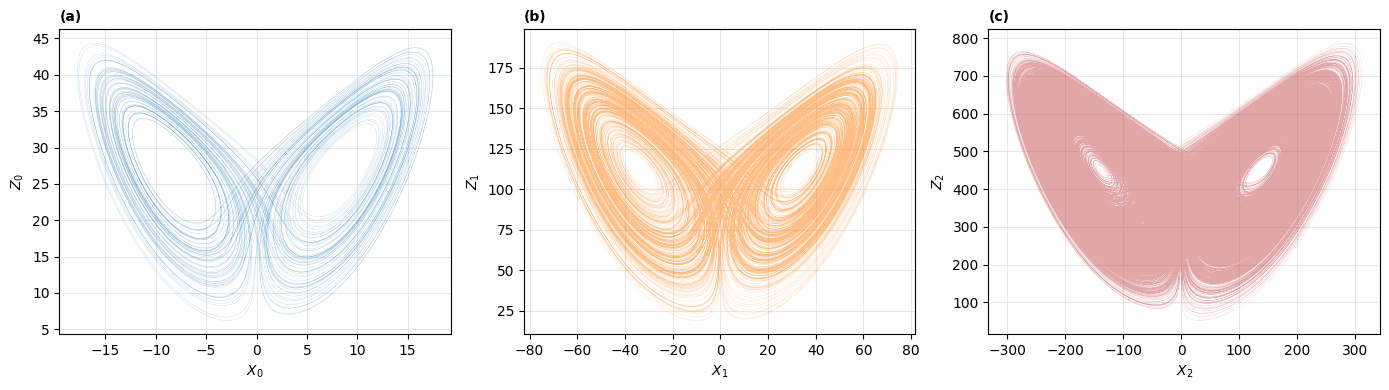

Figure 14 complete.


In [21]:
# ============================================================
# Figure 14: Lorenz Cascade (3-Level)
# ============================================================
sigma0, b0_L, r0_L, lamb_L, c0_L = 10.0, 8/3, 28.0, 2.0, 1.0
sigma1 = sigma0*lamb_L**2; b1_L = b0_L*lamb_L**2
c1_L = c0_L*lamb_L**(2/3); r1_L = r0_L*lamb_L**2
sigma2 = sigma0*lamb_L**4; b2_L = b0_L*lamb_L**4
c2_L = c0_L*lamb_L**(4/3); r2_L = r0_L*lamb_L**4

def cascade_3level(t, state):
    x0,y0,z0,x1,y1,z1,x2,y2,z2 = state
    dx0 = sigma0*(y0-x0)
    dy0 = x0*(r0_L-z0)-y0
    dz0 = x0*y0 - b0_L*z0
    dx1 = sigma1*(y1-x1) + c1_L*(x0-x1)
    dy1 = x1*(r1_L-z1)-y1
    dz1 = x1*y1 - b1_L*z1
    dx2 = sigma2*(y2-x2) + c2_L*(x1-x2)
    dy2 = x2*(r2_L-z2)-y2
    dz2 = x2*y2 - b2_L*z2
    return [dx0,dy0,dz0,dx1,dy1,dz1,dx2,dy2,dz2]

print('Starting Lorenz Cascade integration (this takes ~2 minutes)...')
t_eval_L = np.linspace(0, 120, 2_000_000)
y0_L = [1,1,1, 0.1,0.1,0.1, 0.01,0.01,0.01]
sol_L = solve_ivp(cascade_3level, (0,120), y0_L, t_eval=t_eval_L,
                  method='RK45', rtol=1e-10, atol=1e-13, max_step=0.0005)

skip_L = 500_000
x0_L = sol_L.y[0][skip_L:]; z0_L = sol_L.y[2][skip_L:]
x1_L = sol_L.y[3][skip_L:]; z1_L = sol_L.y[5][skip_L:]
x2_L = sol_L.y[6][skip_L:]; z2_L = sol_L.y[8][skip_L:]
print(f'Integration complete. {len(x0_L)} points after transient.')

df_L = pd.DataFrame({'x0':x0_L[::10],'z0':z0_L[::10],'x1':x1_L[::10],
                     'z1':z1_L[::10],'x2':x2_L[::10],'z2':z2_L[::10]})
df_L.to_csv(os.path.join(OUT_DIR, 'Lorenz_Cascade_Data.csv'), index=False)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, (xn,zn,c,lab,xl,yl,s) in zip(axes, [
    (x0_L,z0_L,'#1f77b4','(a)',r'$X_0$',r'$Z_0$',10),
    (x1_L,z1_L,'#ff7f0e','(b)',r'$X_1$',r'$Z_1$',2),
    (x2_L,z2_L,'#c44e52','(c)',r'$X_2$',r'$Z_2$',1)]):
    ax.plot(xn[::s],zn[::s],color=c,alpha=0.5,lw=0.15)
    ax.set_xlabel(xl); ax.set_ylabel(yl)
    ax.set_title(lab,loc='left',fontweight='bold',fontsize=10)
    ax.grid(True,alpha=0.3)
plt.tight_layout()
fig.savefig(os.path.join(OUT_DIR, 'fig_lorenz_cascade.png'), dpi=300, bbox_inches='tight')
plt.show()
print('Figure 14 complete.')

---
## Figure 15: Spatiotemporal dynamics of the Kuramoto multi-scale cascade

(a) Macroscopic phase cos(θ₀) exhibiting burst/quiet cycles. (b) Dynamic sub-scale coupling κ_eff(t) versus intrinsic frequency ω₁. (c) Sub-structure phase sin(θ₁) illustrating intermittent structural enslavement and phase slipping.

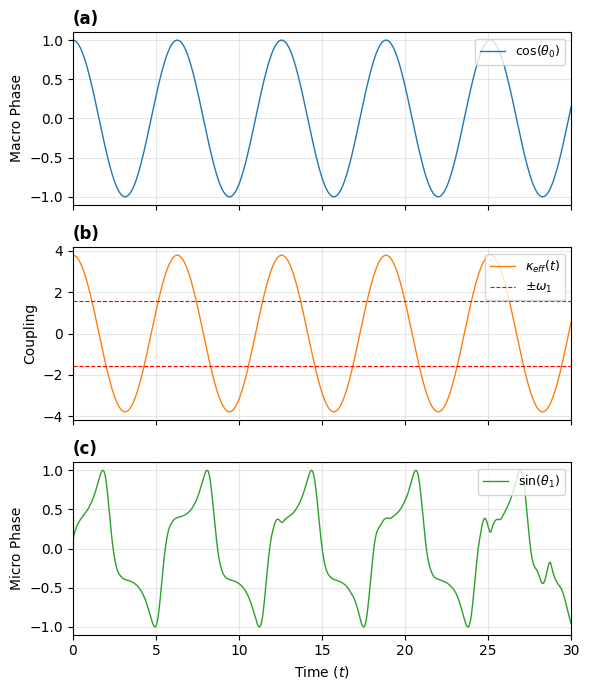

Figure 15 complete.


In [22]:
# ============================================================
# Figure 15: Kuramoto Cascade
# ============================================================
omega_0_kc = 1.0; lamb_kc = 2.0; z_kc = 2.0/3.0
omega_1_kc = omega_0_kc * lamb_kc**z_kc
kappa_base_kc = 3.0
kappa_eff_kc = kappa_base_kc * lamb_kc**(1.0/3.0)

def kuramoto_cascade(t, state):
    theta0, theta1 = state
    return [omega_0_kc, omega_1_kc - kappa_eff_kc*np.cos(theta0)*np.sin(theta1)]

t_kc = np.linspace(0, 30, 3000)
sol_kc = solve_ivp(kuramoto_cascade, (0,30), [0.0,0.1], t_eval=t_kc)
theta0_kc, theta1_kc = sol_kc.y[0], sol_kc.y[1]
eff_coup = kappa_eff_kc * np.cos(theta0_kc)

df_kc = pd.DataFrame({'Time':t_kc, 'Theta0':theta0_kc, 'Theta1':theta1_kc,
                       'EffectiveCoupling':eff_coup})
df_kc.to_csv(os.path.join(OUT_DIR, 'Kuramoto_Cascade_Data.csv'), index=False)

fig, axs = plt.subplots(3, 1, figsize=(6, 7), sharex=True)
axs[0].plot(t_kc, np.cos(theta0_kc), color='#1f77b4', lw=1)
axs[0].set_ylabel('Macro Phase'); axs[0].set_title('(a)',loc='left',fontweight='bold')
axs[0].legend([r'$\cos(\theta_0)$'],loc='upper right',fontsize=9); axs[0].grid(True,alpha=0.3)

axs[1].plot(t_kc, eff_coup, color='#ff7f0e', lw=1)
axs[1].axhline(omega_1_kc,color='red',ls='--',lw=0.8)
axs[1].axhline(-omega_1_kc,color='red',ls='--',lw=0.8)
axs[1].set_ylabel('Coupling'); axs[1].set_title('(b)',loc='left',fontweight='bold')
axs[1].legend([r'$\kappa_{eff}(t)$',r'$\pm\omega_1$'],loc='upper right',fontsize=9)
axs[1].grid(True,alpha=0.3)

axs[2].plot(t_kc, np.sin(theta1_kc), color='#2ca02c', lw=1)
axs[2].set_ylabel('Micro Phase'); axs[2].set_xlabel('Time ($t$)')
axs[2].set_title('(c)',loc='left',fontweight='bold')
axs[2].legend([r'$\sin(\theta_1)$'],loc='upper right',fontsize=9); axs[2].grid(True,alpha=0.3)
axs[2].set_xlim(0,30)

plt.tight_layout()
fig.savefig(os.path.join(OUT_DIR, 'fig_kuramoto_cascade.png'), dpi=300, bbox_inches='tight')
plt.show()
print('Figure 15 complete.')